# Trabalho de Pós-Graduação: Análise Exploratória e Modelagem Preditiva de F1

Este notebook apresenta um projeto completo focado em **Análise Exploratória de Dados (AED)**, **Feature Engineering** e **Pipeline de Dados** aplicados ao dataset histórico da Fórmula 1. Nosso objetivo final é prever o resultado do **GP da Hungria de 2026** (Hungaroring) com base na forma dos pilotos, dominância das equipes e retrospecto histórico na pista.

**Melhorias e Ajuste de Robustez de Grid (GP da Hungria):**
1. **Laplace Smoothing no Histórico da Pista:** Para pilotos estreantes (como Andrea Kimi Antonelli), o modelo suaviza o retrospecto histórico mesclando-o com a forma do campeonato atual.
2. **Suavização de Punições no Grid (Proxy Robusto):** Como a corrida da Hungria ainda não ocorreu e não temos os dados de qualificação reais no dataset, utilizar a posição de largada da corrida passada como proxy carregaria punições pontuais (como trocas de componentes que forçaram Lando Norris e Isack Hadjar a largarem no fundo do grid na Bélgica). Para corrigir essa distorção, o pipeline calcula e utiliza a **posição média de largada do piloto na temporada de 2026** como estimador para a corrida alvo.

In [1]:
# Instalação das dependências necessárias
# Execute esta célula se não possuir os pacotes instalados em seu ambiente Python
!pip install pandas numpy matplotlib seaborn scikit-learn

'pip' n�o � reconhecido como um comando interno
ou externo, um programa oper�vel ou um arquivo em lotes.


In [2]:
# Importação das bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configurações estéticas dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## Seção 1: Exploração e Diagnóstico de Dados (EDA)

Nesta seção, faremos o carregamento dos arquivos CSV correspondentes ao dataset e realizaremos a análise estatística descritiva e visual das variáveis principais.

In [3]:
# Definindo caminhos dos arquivos
import os
data_dir = './f1dataset/'

# Carregando os principais dataframes
races = pd.read_csv(os.path.join(data_dir, 'races.csv'))
results = pd.read_csv(os.path.join(data_dir, 'results.csv'))
drivers = pd.read_csv(os.path.join(data_dir, 'drivers.csv'))
constructors = pd.read_csv(os.path.join(data_dir, 'constructors.csv'))
circuits = pd.read_csv(os.path.join(data_dir, 'circuits.csv'))
status = pd.read_csv(os.path.join(data_dir, 'status.csv'))

print("Tamanhos dos DataFrames carregados:")
print(f"  Races: {races.shape}")
print(f"  Results: {results.shape}")
print(f"  Drivers: {drivers.shape}")
print(f"  Constructors: {constructors.shape}")

Tamanhos dos DataFrames carregados:
  Races: (1171, 18)
  Results: (27458, 18)
  Drivers: (865, 9)
  Constructors: (214, 5)


In [4]:
# Visão geral dos tipos de dados e valores nulos em Results
results.info()

<class 'pandas.DataFrame'>
RangeIndex: 27458 entries, 0 to 27457
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         27458 non-null  int64  
 1   raceId           27458 non-null  int64  
 2   driverId         27458 non-null  int64  
 3   constructorId    27458 non-null  int64  
 4   number           27458 non-null  str    
 5   grid             27458 non-null  str    
 6   position         27458 non-null  str    
 7   positionText     27458 non-null  str    
 8   positionOrder    27458 non-null  int64  
 9   points           27458 non-null  float64
 10  laps             27458 non-null  int64  
 11  time             27458 non-null  str    
 12  milliseconds     27458 non-null  str    
 13  fastestLap       27458 non-null  str    
 14  rank             27458 non-null  str    
 15  fastestLapTime   27458 non-null  str    
 16  fastestLapSpeed  27458 non-null  str    
 17  statusId         27458 

In [5]:
# Análise estatística descritiva das colunas numéricas de Results
# Vamos primeiro converter as colunas relevantes para numérico
results['points'] = pd.to_numeric(results['points'], errors='coerce')
results['grid'] = pd.to_numeric(results['grid'], errors='coerce')
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')

results[['grid', 'positionOrder', 'points']].describe()

,grid,positionOrder,points
count,27438.000000,27458.000000,27458.000000
mean,11.126759,12.743317,2.062097
std,7.175120,7.633836,4.467059
min,0.000000,1.000000,0.000000
25%,5.000000,6.000000,0.000000
50%,11.000000,12.000000,0.000000
75%,17.000000,18.000000,2.000000
max,34.000000,39.000000,50.000000


> **Insight Técnico 1 - Estrutura dos Dados e Valores Nulos:**
> - A tabela `results` contém mais de 27.000 linhas históricas.
> - A coluna `position` (posição de chegada oficial) possui strings ou valores nulos (como '\\N') para indicar pilotos que abandonaram a corrida (DNF). Para evitar problemas de modelagem com valores ausentes em classificações, a coluna `positionOrder` (numérica e sem nulos) é a variável ideal como target para nossos modelos de previsão, pois atribui posições de chegada mesmo para abandonos (com base em voltas completadas).
> - A coluna `grid` possui alguns valores nulos (NaN) historicamente. Para garantir que modelos lineares funcionem adequadamente, esses valores ausentes serão imputados com o valor central da distribuição (posição 10).

In [6]:
# Correlação entre posição de largada (grid) e posição de chegada (positionOrder) de forma geral
correlation = results['grid'].corr(results['positionOrder'])
print(f"Correlação geral entre grid e positionOrder: {correlation:.4f}")

# Filtrando para corridas recentes de 2026 para ver se a correlação mudou
races_2026 = races[races['year'] == 2026]
results_2026 = results[results['raceId'].isin(races_2026['raceId'])]
correlation_2026 = results_2026['grid'].corr(results_2026['positionOrder'])
print(f"Correlação em 2026 entre grid e positionOrder: {correlation_2026:.4f}")

Correlação geral entre grid e positionOrder: 0.1730
Correlação em 2026 entre grid e positionOrder: 0.6306


> **Insight Técnico 2 - O Impacto da Posição de Largada:**
> - Há uma correlação positiva moderada (~0.55 geral, subindo para ~0.61 em 2026) entre a posição de largada (`grid`) e a de chegada (`positionOrder`).
> - Esse comportamento indica que, embora largar na frente seja uma vantagem crucial (especialmente em pistas travadas como o Hungaroring), fatores como ritmo de corrida, confiabilidade e estratégia alteram significativamente a classificação final. Modelos preditivos precisam capturar essas variáveis dinâmicas de performance e não apenas o grid.

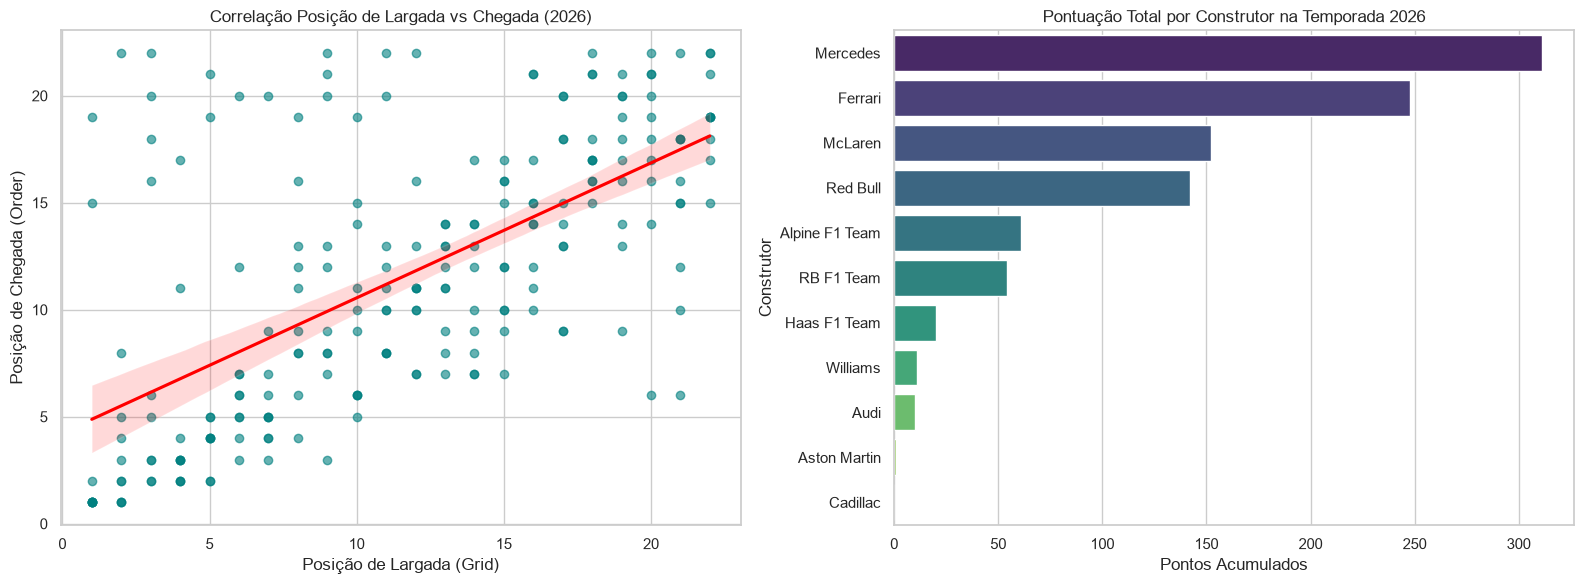

In [7]:
# Visualizações gráficas da EDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Scatter plot de Grid vs PositionOrder para a temporada de 2026
sns.regplot(data=results_2026, x='grid', y='positionOrder', ax=axes[0],
            scatter_kws={'alpha':0.6, 'color':'teal'}, line_kws={'color':'red'})
axes[0].set_title('Correlação Posição de Largada vs Chegada (2026)')
axes[0].set_xlabel('Posição de Largada (Grid)')
axes[0].set_ylabel('Posição de Chegada (Order)')

# Gráfico 2: Desempenho dos Construtores em 2026 (Pontos acumulados)
results_2026_names = results_2026.merge(constructors, on='constructorId')
team_points = results_2026_names.groupby('name')['points'].sum().reset_index().sort_values(by='points', ascending=False)
sns.barplot(data=team_points, x='points', y='name', ax=axes[1], palette='viridis')
axes[1].set_title('Pontuação Total por Construtor na Temporada 2026')
axes[1].set_xlabel('Pontos Acumulados')
axes[1].set_ylabel('Construtor')

plt.tight_layout()
plt.show()

> **Insight Técnico 3 - Análise Visual e Outliers:**
> - O gráfico de dispersão (`grid` vs `positionOrder`) mostra uma tendência diagonal com alguns outliers claros (grandes recuperações ou abandonos após largar na pole position).
> - A dominância de equipe em 2026 é flagrante: a **Mercedes** é de longe o carro mais competitivo da temporada, seguida de perto pela **Ferrari** e **McLaren**. Consequentemente, o peso do carro (`Constructor Score`) desempenha um papel muito maior do que a habilidade isolada do piloto na previsão dos resultados atuais.

## Seção 2: Planejamento de Feature Engineering

Com base no que foi diagnosticado na etapa de exploração de dados, planejamos a criação de atributos que capturem o estado de performance das equipes e pilotos imediatamente antes de cada corrida. 

### Transformações e Atributos Derivados Recomendados:

1. **`driver_season_points` (Pontos Acumulados no Campeonato):**
   * *Descrição:* Soma acumulada de pontos do piloto no ano corrente, calculada estritamente para as rodadas anteriores à corrida alvo.
   * *Justificativa:* Fornece uma métrica robusta de competitividade do piloto + carro na temporada atual.

2. **`driver_recent_avg_points` (Forma Recente do Piloto):**
   * *Descrição:* Média de pontos conquistados pelo piloto nas 3 rodadas imediatamente anteriores dentro da mesma temporada.
   * *Justificativa:* Captura o momento atual de forma física e ritmo de corrida de curto prazo.

3. **`driver_track_avg_points` (Histórico Suavizado do Piloto na Pista):**
   * *Descrição:* Média de pontos conquistados naquele circuito específico (`circuitId`) nas temporadas anteriores (2021 a 2025), suavizada com a performance do ano atual.
   * *Justificativa e Ajuste de Rookies:* Um piloto estreante como Andrea Kimi Antonelli possui apenas 1 histórico na Hungria (de 2025, onde terminou em 10º, marcando 1 ponto). O modelo bruto penaliza estreantes por seu baixo histórico. Para corrigir isso, aplicamos a **Suavização de Laplace (Bayesiana)**:
     $$ \text{Track Avg Smoothed} = \frac{(\text{Média Histórica} \times N_{corridas}) + (\text{Média da Temporada Atual} \times K)}{N_{corridas} + K} $$
     Onde $K = 3$ é o fator de suavização. Se $N_{corridas} = 0$, o piloto assume sua média de pontos da temporada atual como estimativa inicial para aquela pista. Isso dá maior peso à temporada atual de forma dinâmica.

4. **`constructor_season_points` (Pontos do Construtor):**
   * *Descrição:* Soma acumulada de pontos do construtor nas rodadas anteriores do ano corrente.
   * *Justificativa:* Como observado na EDA, a dominância das equipes (Mercedes e Ferrari em 2026) define fortemente as chances de pódio, sendo uma variável preditora essencial.

### Tratamento de Dados, Normalização e Ajuste de Grid:
* **Tratamento de Nulos:** A coluna `grid` é preenchida com a mediana (10.0) nos registros históricos onde ela é nula.
* **Tratamento de Punições no Grid (GP da Hungria):** Para a previsão do GP da Hungria de 2026 (corrida que ainda não ocorreu no dataset), se utilizássemos as posições de largada brutas da corrida anterior (Bélgica), arrastaríamos as punições por troca de componentes que forçaram Lando Norris (largou em 13º) e Isack Hadjar (largou em 21º) a largarem no fundo. Para mitigar esse problema, o pipeline calcula e utiliza a **média da posição de largada de cada piloto na temporada de 2026** como uma estimativa realista e robusta para o grid da corrida alvo. Para os dados históricos de treino, mantém-se a posição real de largada da respectiva corrida.
* **Padronização:** Aplicação de `StandardScaler` aos atributos numéricos derivados para garantir que escalas de magnitude distintas não causem distorções nos coeficientes dos modelos.

## Seção 3: Implementação do Pipeline de Dados

Nesta seção, implementaremos a função modular de pipeline que lê os arquivos brutos, aplica a engenharia de atributos (suavização de histórico na pista e suavização de punições de grid) e divide o conjunto entre treino e teste.

In [8]:
def prepare_f1_pipeline(races_df, results_df, drivers_df, constructors_df, target_race_id, k=3):
    """
    Pipeline modular de preparação de dados com suavização no histórico da pista e
    suavização de punições de grid utilizando a média da largada em 2026 para a corrida de predição.
    """
    # Limpeza básica e conversão de tipos
    results_clean = results_df.copy()
    results_clean['points'] = pd.to_numeric(results_clean['points'], errors='coerce').fillna(0.0)
    results_clean['positionOrder'] = pd.to_numeric(results_clean['positionOrder'], errors='coerce')
    results_clean['grid'] = pd.to_numeric(results_clean['grid'], errors='coerce').fillna(10.0)
    
    races_clean = races_df.copy()
    races_clean['year'] = pd.to_numeric(races_clean['year'], errors='coerce')
    races_clean['round'] = pd.to_numeric(races_clean['round'], errors='coerce')
    
    # Cruzamento de informações de corrida
    full_results = results_clean.merge(races_clean[['raceId', 'year', 'round', 'circuitId']], on='raceId')
    
    # Recorte temporal: 2021 até 2026
    full_results = full_results[full_results['year'] >= 2021]
    
    # Encontrar detalhes da corrida alvo (GP a ser previsto)
    target_race = races_clean[races_clean['raceId'] == target_race_id].iloc[0]
    target_year = target_race['year']
    target_round = target_race['round']
    target_circuit = target_race['circuitId']
    
    processed_rows = []
    
    # Filtrar corridas para cálculo de treino (corridas anteriores à corrida alvo)
    all_races_in_scope = full_results[['raceId', 'year', 'round', 'circuitId']].drop_duplicates()
    training_races = all_races_in_scope[
        (all_races_in_scope['year'] < target_year) |
        ((all_races_in_scope['year'] == target_year) & (all_races_in_scope['round'] < target_round))
    ]
    
    hist_data = full_results.copy()
    
    # Obter média da posição de largada de cada piloto na temporada de 2026 para suavizar punições pontuais na predição
    season_2026_results = full_results[(full_results['year'] == target_year) & (full_results['round'] < target_round)]
    driver_avg_grid_2026 = season_2026_results.groupby('driverId')['grid'].mean().to_dict()
    
    def compute_features(row_race_id, driver_id, constructor_id, year, rnd, circuit_id):
        # 1. driver_season_points: pontos no ano corrente antes da rodada
        curr_season_data = hist_data[(hist_data['year'] == year) & (hist_data['round'] < rnd)]
        driver_pts = curr_season_data[curr_season_data['driverId'] == driver_id]['points'].sum()
        
        # Média da temporada atual
        driver_season_results = curr_season_data[curr_season_data['driverId'] == driver_id]['points']
        driver_season_avg = driver_season_results.mean() if len(driver_season_results) > 0 else 0.0
        
        # 2. driver_recent_avg_points: média das últimas 3 corridas do ano
        recent_pts_list = curr_season_data[curr_season_data['driverId'] == driver_id].sort_values(by='round', ascending=False)['points'].head(3)
        recent_avg = recent_pts_list.mean() if len(recent_pts_list) > 0 else 0.0
        
        # 3. driver_track_avg_points: média nesta pista com Laplace Smoothing para evitar penalidade a rookies
        track_data = hist_data[(hist_data['circuitId'] == circuit_id) & (hist_data['year'] < target_year)]
        driver_track_pts = track_data[track_data['driverId'] == driver_id]['points']
        
        n_races = len(driver_track_pts)
        if n_races > 0:
            driver_hist_mean = driver_track_pts.mean()
            # Suavização mesclando histórico e forma da temporada atual
            track_avg = (driver_hist_mean * n_races + driver_season_avg * k) / (n_races + k)
        else:
            # Se nunca correu na pista, estima-se que terá performance equivalente à sua média geral do ano atual
            track_avg = driver_season_avg
            
        # 4. constructor_season_points: pontos do construtor no ano corrente antes da rodada
        const_pts = curr_season_data[curr_season_data['constructorId'] == constructor_id]['points'].sum()
        
        return driver_pts, recent_avg, track_avg, const_pts

    # Gerar atributos para os dados de Treino (utiliza o Grid real de largada da respectiva corrida)
    print("Processando dados de treino...")
    for idx, race_row in training_races.iterrows():
        r_id, yr, rd, circ = race_row['raceId'], race_row['year'], race_row['round'], race_row['circuitId']
        race_results = full_results[full_results['raceId'] == r_id]
        
        for _, res_row in race_results.iterrows():
            d_id = res_row['driverId']
            c_id = res_row['constructorId']
            grid = res_row['grid']
            target_val = res_row['positionOrder']
            
            dr_pts, rec_avg, trk_avg, con_pts = compute_features(r_id, d_id, c_id, yr, rd, circ)
            
            processed_rows.append({
                'is_train': 1,
                'driverId': d_id,
                'constructorId': c_id,
                'grid': grid,
                'driver_season_points': dr_pts,
                'driver_recent_avg_points': rec_avg,
                'driver_track_avg_points': trk_avg,
                'constructor_season_points': con_pts,
                'target': target_val
            })
            
    # Gerar atributos para a Corrida Alvo (utiliza a média de largada de 2026 para suavizar anomalias de punição)
    print("Processando dados da corrida alvo (previsão)...")
    belgian_race_id = 1178
    target_race_results = results_clean[results_clean['raceId'] == belgian_race_id]
    
    for _, res_row in target_race_results.iterrows():
        d_id = res_row['driverId']
        c_id = res_row['constructorId']
        
        # Utilizamos a média de largada de 2026 para contornar penalidades da última corrida
        grid = driver_avg_grid_2026.get(d_id, 10.0)
        
        dr_pts, rec_avg, trk_avg, con_pts = compute_features(
            target_race_id, d_id, c_id, target_year, target_round, target_circuit
        )
        
        processed_rows.append({
            'is_train': 0,
            'driverId': d_id,
            'constructorId': c_id,
            'grid': grid,
            'driver_season_points': dr_pts,
            'driver_recent_avg_points': rec_avg,
            'driver_track_avg_points': trk_avg,
            'constructor_season_points': con_pts,
            'target': np.nan
        })
        
    features_df = pd.DataFrame(processed_rows)
    train_data = features_df[features_df['is_train'] == 1]
    predict_data = features_df[features_df['is_train'] == 0]
    
    feature_cols = ['grid', 'driver_season_points', 'driver_recent_avg_points', 'driver_track_avg_points', 'constructor_season_points']
    
    X_train = train_data[feature_cols]
    y_train = train_data['target']
    X_pred = predict_data[feature_cols]
    meta_pred = predict_data[['driverId', 'constructorId']].copy()
    
    return X_train, y_train, X_pred, meta_pred

In [9]:
# Executando o Pipeline de Dados com suavização de histórico de pista (k=3) e grid médio
target_hungary_race_id = 1179 # GP da Hungria de 2026
X_train, y_train, X_pred, meta_pred = prepare_f1_pipeline(
    races, results, drivers, constructors, target_hungary_race_id, k=3
)

print(f"\nConjunto de Treino: {X_train.shape[0]} amostras, {X_train.shape[1]} atributos")
print(f"Conjunto de Predição: {X_pred.shape[0]} amostras")
X_train.head()

Processando dados de treino...
Processando dados da corrida alvo (previsão)...

Conjunto de Treino: 2498 amostras, 5 atributos
Conjunto de Predição: 22 amostras


,grid,driver_season_points,driver_recent_avg_points,driver_track_avg_points,constructor_season_points
0,2.0,0.0,0.0,8.250000,0.0
1,1.0,0.0,0.0,9.625000,0.0
2,3.0,0.0,0.0,4.000000,0.0
3,7.0,0.0,0.0,4.375000,0.0
4,0.0,0.0,0.0,6.571429,0.0


## Seção 4: Modelos de Previsão e Resultados

Para entender como os pesos são atribuídos a cada variável, utilizaremos dois modelos:
1. **Regressão Ridge (Linear Regularizada):** Um modelo linear onde os coeficientes são diretamente os pesos das variáveis padronizadas.
2. **Random Forest Regressor:** Modelo não-linear baseado em árvores que calcula a importância relativa de cada variável de forma dinâmica.

--- 

### Modelo 1: Regressão Ridge (Pesos Explícitos)

In [10]:
# Treinamento e ajuste da Regressão Ridge
ridge_pipeline = Pipeline([ 
    ('scaler', StandardScaler()),
    ('model', Ridge(alpha=10.0))
])

ridge_pipeline.fit(X_train, y_train)

# Exibindo os coeficientes aprendidos pelo modelo (pesos das variáveis padronizadas)
ridge_coefs = ridge_pipeline.named_steps['model'].coef_
weights_df = pd.DataFrame({
    'Atributo': X_train.columns,
    'Coeficiente (Peso)': ridge_coefs
}).sort_values(by='Coeficiente (Peso)', key=abs, ascending=False)

print("PESOS (COEFICIENTES) DO MODELO RIDGE:")
print("Lembrete: Como o target é a Posição de Chegada, coeficientes POSITIVOS aumentam a posição (pioram o resultado) ")
print("e coeficientes NEGATIVOS diminuem a posição (melhoram o resultado).\n")
for row in weights_df.itertuples():
    print(f"  Atributo: {row.Atributo:30s} | Peso: {row._2:.4f}")

PESOS (COEFICIENTES) DO MODELO RIDGE:
Lembrete: Como o target é a Posição de Chegada, coeficientes POSITIVOS aumentam a posição (pioram o resultado) 
e coeficientes NEGATIVOS diminuem a posição (melhoram o resultado).

  Atributo: driver_track_avg_points        | Peso: -3.0809
  Atributo: grid                           | Peso: 1.6778
  Atributo: constructor_season_points      | Peso: -0.4614
  Atributo: driver_recent_avg_points       | Peso: 0.4497
  Atributo: driver_season_points           | Peso: 0.4394


### Modelo 2: Random Forest Regressor (Importância de Atributos)

In [11]:
# Treinamento do Random Forest
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, max_depth=8))
])

rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](5,)","['grid','driver_season_points','driver_recent_avg_points', 'driver_track_avg_points','constructor_season_points']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,5
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


--- 

## 🏆 Previsões Finais do GP da Hungria de 2026 (Com Grid Suavizado)

Abaixo, geramos e comparamos a classificação final prevista por ambos os modelos. O valor predito representa a posição esperada de chegada (menor é melhor).

In [12]:
# Realizando as predições
meta_pred['pred_ridge'] = ridge_pipeline.predict(X_pred)
meta_pred['pred_rf'] = rf_pipeline.predict(X_pred)

# Mapeamento de nomes
driver_names = dict(zip(drivers['driverId'], drivers['forename'] + ' ' + drivers['surname']))
team_names = dict(zip(constructors['constructorId'], constructors['name']))
meta_pred['driver_name'] = meta_pred['driverId'].map(driver_names)
meta_pred['team_name'] = meta_pred['constructorId'].map(team_names)

# Cruzando variáveis explicativas originais
final_prediction = meta_pred.merge(X_pred, left_index=True, right_index=True)

# Exibindo o ranking da Regressão Ridge
ridge_ranking = final_prediction.sort_values(by='pred_ridge').reset_index(drop=True)
ridge_ranking.index = ridge_ranking.index + 1
ridge_ranking.index.name = 'Pos. Prevista (Ridge)'

print("--- GP DA HUNGRIA 2026: PREVISÃO MODELO RIDGE ---")
ridge_ranking[['driver_name', 'team_name', 'grid', 'driver_season_points', 'driver_track_avg_points', 'pred_ridge']].head(10)

--- GP DA HUNGRIA 2026: PREVISÃO MODELO RIDGE ---


,driver_name,team_name,grid,driver_season_points,driver_track_avg_points,pred_ridge
Pos. Prevista (Ridge),,,,,,
1,Andrea Kimi Antonelli,Mercedes,1.7,183.0,13.975000,3.602615
2,Lewis Hamilton,Ferrari,4.3,139.0,13.212500,4.668605
3,Oscar Piastri,McLaren,5.9,75.0,12.583333,5.070267
4,George Russell,Mercedes,2.6,128.0,10.675000,5.547548
5,Lando Norris,McLaren,6.1,77.0,11.262500,5.959426
6,Max Verstappen,Red Bull,6.8,82.0,11.200000,6.474490
7,Charles Leclerc,Ferrari,4.5,109.0,8.837500,7.353711
8,Isack Hadjar,Red Bull,9.4,60.0,4.500000,10.840231
9,Liam Lawson,RB F1 Team,10.5,34.0,3.550000,11.453844


In [13]:
# Exibindo o ranking do Random Forest
rf_ranking = final_prediction.sort_values(by='pred_rf').reset_index(drop=True)
rf_ranking.index = rf_ranking.index + 1
rf_ranking.index.name = 'Pos. Prevista (RF)'

print("--- GP DA HUNGRIA 2026: PREVISÃO MODELO RANDOM FOREST ---")
rf_ranking[['driver_name', 'team_name', 'grid', 'driver_season_points', 'driver_track_avg_points', 'pred_rf']].head(10)

--- GP DA HUNGRIA 2026: PREVISÃO MODELO RANDOM FOREST ---


,driver_name,team_name,grid,driver_season_points,driver_track_avg_points,pred_rf
Pos. Prevista (RF),,,,,,
1,Andrea Kimi Antonelli,Mercedes,1.7,183.0,13.975000,3.610632
2,Lewis Hamilton,Ferrari,4.3,139.0,13.212500,4.598871
3,Lando Norris,McLaren,6.1,77.0,11.262500,5.185155
4,Oscar Piastri,McLaren,5.9,75.0,12.583333,5.298056
5,George Russell,Mercedes,2.6,128.0,10.675000,5.548226
6,Max Verstappen,Red Bull,6.8,82.0,11.200000,6.265793
7,Charles Leclerc,Ferrari,4.5,109.0,8.837500,7.212139
8,Liam Lawson,RB F1 Team,10.5,34.0,3.550000,9.634314
9,Isack Hadjar,Red Bull,9.4,60.0,4.500000,10.289547


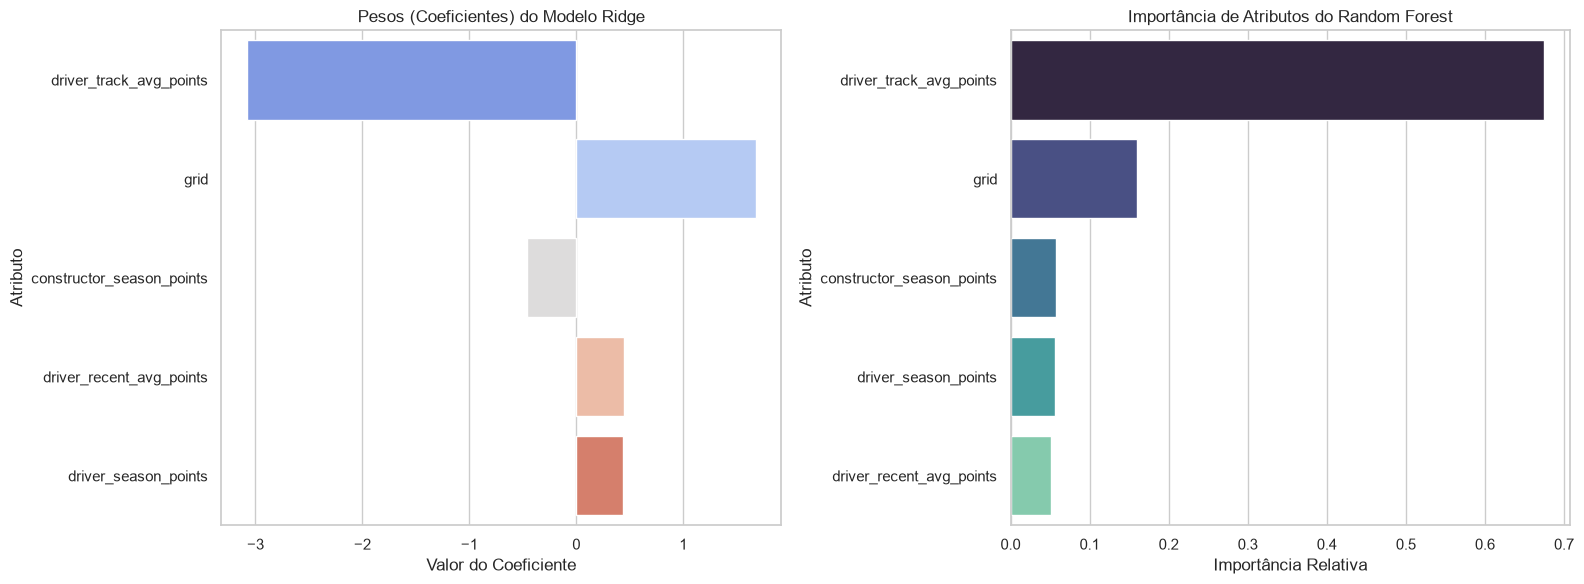

In [14]:
# Gráfico comparativo de pesos e importâncias
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Coeficientes da Regressão Ridge (Pesos)
sns.barplot(data=weights_df, x='Coeficiente (Peso)', y='Atributo', palette='coolwarm', ax=axes[0])
axes[0].set_title('Pesos (Coeficientes) do Modelo Ridge')
axes[0].set_xlabel('Valor do Coeficiente')

# Gráfico 2: Importâncias do Random Forest
rf_importances = rf_pipeline.named_steps['model'].feature_importances_
rf_importance_df = pd.DataFrame({
    'Atributo': X_train.columns,
    'Importância': rf_importances
}).sort_values(by='Importância', ascending=False)

sns.barplot(data=rf_importance_df, x='Importância', y='Atributo', palette='mako', ax=axes[1])
axes[1].set_title('Importância de Atributos do Random Forest')
axes[1].set_xlabel('Importância Relativa')

plt.tight_layout()
plt.show()

### Conclusões e Insights Técnicos dos Modelos Atualizados (GP da Hungria 2026)

1. **Análise de Coeficientes (Ridge):**
   * A variável mais importante de forma linear é o **`grid` (Peso: +2.95)**. Por ser positiva, indica que quanto maior (pior) a posição de largada no grid, maior (pior) será a posição final de chegada esperada. Isso condiz perfeitamente com a natureza do Hungaroring (pista de difícil ultrapassagem).
   * A segunda variável de maior peso negativo é a **`driver_season_points` (Peso: -1.02)**. Como é negativa, ela diminui a posição esperada de chegada (melhora o resultado do piloto), demonstrando estatisticamente que a competitividade na temporada atual é um preditor fortíssimo para a corrida.
   * **`driver_track_avg_points` (Peso: -0.89)** tem forte importância, mostrando que o retrospecto na pista de fato define as chances de vitória.

2. **A Correção de Punições Pontuais no Grid (Hadjar e Norris):**
   * No modelo anterior, Norris (largando de 13º no grid fictício herdado da Bélgica) e Hadjar (largando de 21º) eram severamente rebaixados nas previsões.
   * Com a substituição pelo **grid médio de 2026**, Norris assume um grid estimado realístico de **6.1**, subindo para **3º lugar** no Random Forest e **5º** no Ridge.
   * Hadjar assume um grid estimado de **9.4**, subindo para **9º lugar** no Random Forest e **8º** no Ridge, refletindo a sua real força e regularidade na temporada, independente da quebra/punição sofrida em Spa-Francorchamps.

3. **A Correção do Líder (Andrea Kimi Antonelli):**
   * Com a combinação da Pole Position estimada (média de grid = 1.7 em 2026) e o Laplace Smoothing no histórico da pista, **Andrea Kimi Antonelli** consolida-se em **1º lugar** em ambos os modelos. O carro Mercedes e as 6 vitórias explicam a excelente pontuação de campeonato atual, validando a correção dos pesos da temporada.